<a href="https://colab.research.google.com/github/europecodingschool/ECS---VB---YZ---08.26/blob/main/VB_YZ_Ders_15_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
veri = pd.read_csv("/content/kredi_basvurulari.csv")

In [6]:
veri.head()

,yas,aylik_gelir,calisma_yili,kredi_tutari,vade_ay,borc_gelir_orani,gecmis_gecikme,ev_durumu,kredi_amaci,basvuru_gunu,kredi_durumu
0,41,34300,6,68000,60,0.05,0,Aile yani,Egitim,Paz,Odedi
1,28,31100,3,327000,24,0.20,1,Kira,Tasit,Cum,Odedi
2,46,51100,14,118000,12,0.11,1,Ev sahibi,Tasit,Car,Odedi
3,47,47000,16,332000,36,0.42,0,Aile yani,Konut,Car,Odedi
4,21,22300,0,139000,36,0.03,1,Aile yani,Tasit,Cmt,Odedi


In [8]:
veri.shape

(2000, 11)

In [10]:
veri.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   yas               2000 non-null   int64  
 1   aylik_gelir       2000 non-null   int64  
 2   calisma_yili      2000 non-null   int64  
 3   kredi_tutari      2000 non-null   int64  
 4   vade_ay           2000 non-null   int64  
 5   borc_gelir_orani  2000 non-null   float64
 6   gecmis_gecikme    2000 non-null   int64  
 7   ev_durumu         2000 non-null   object 
 8   kredi_amaci       2000 non-null   object 
 9   basvuru_gunu      2000 non-null   object 
 10  kredi_durumu      2000 non-null   object 
dtypes: float64(1), int64(6), object(4)
memory usage: 172.0+ KB


In [12]:
veri.isnull().sum()

,0
yas,0
aylik_gelir,0
calisma_yili,0
kredi_tutari,0
vade_ay,0
borc_gelir_orani,0
gecmis_gecikme,0
ev_durumu,0
kredi_amaci,0
basvuru_gunu,0


In [14]:
veri.describe()

,yas,aylik_gelir,calisma_yili,kredi_tutari,vade_ay,borc_gelir_orani,gecmis_gecikme
count,2000.00000,2000.00000,2000.000000,2.000000e+03,2000.000000,2000.000000,2000.000000
mean,37.65800,46855.25000,8.197500,3.159695e+05,34.608000,0.300495,0.735500
std,9.55896,22270.02738,6.515882,2.136870e+05,14.673854,0.159396,0.867131
min,21.00000,17000.00000,0.000000,2.900000e+04,12.000000,0.010000,0.000000
25%,31.00000,31075.00000,3.000000,1.607500e+05,24.000000,0.180000,0.000000
50%,38.00000,42300.00000,7.000000,2.650000e+05,36.000000,0.280000,1.000000
75%,44.00000,57100.00000,12.000000,4.202500e+05,48.000000,0.400000,1.000000
max,68.00000,168600.00000,37.000000,1.670000e+06,60.000000,0.880000,5.000000


In [16]:
# Hedef değişken ="kredi durumu" yüzdelik ve adet olarak.
veri["kredi_durumu"].value_counts()

,count
kredi_durumu,
Odedi,1493
Temerrut,507


In [21]:
veri["kredi_durumu"].value_counts(normalize=True).round(2)

,proportion
kredi_durumu,
Odedi,0.75
Temerrut,0.25


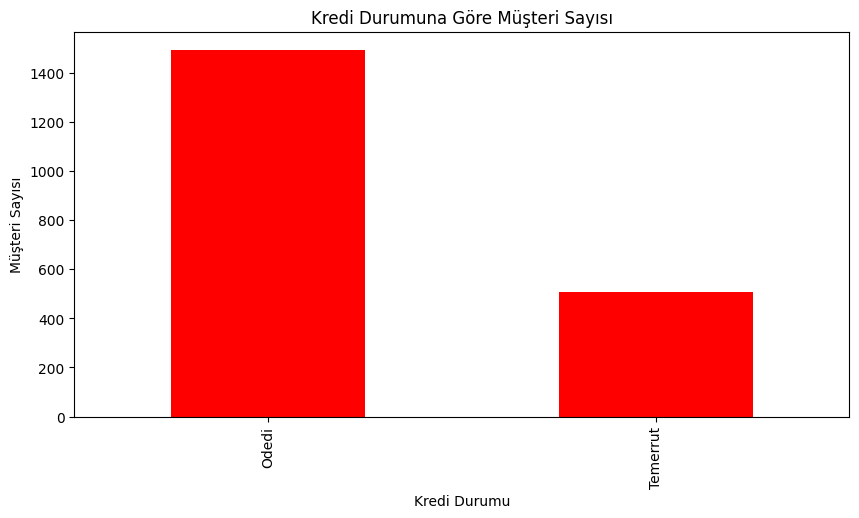

In [25]:
plt.figure(figsize=(10,5))
veri["kredi_durumu"].value_counts().plot(kind="bar", color="r")
plt.title("Kredi Durumuna Göre Müşteri Sayısı")
plt.xlabel("Kredi Durumu")
plt.ylabel("Müşteri Sayısı")
plt.show()


In [27]:
#geçmiş gecikmelere analizi

gecikme_tablosu = pd.crosstab(veri['gecmis_gecikme'], veri['kredi_durumu'])
gecikme_tablosu

kredi_durumu,Odedi,Temerrut
gecmis_gecikme,,
0,777,184
1,565,145
2,120,126
3,27,38
4,4,12
5,0,2


In [29]:
gecikme_tablosu = pd.crosstab(veri['gecmis_gecikme'], veri['kredi_durumu'], normalize="index").round(2)
gecikme_tablosu

kredi_durumu,Odedi,Temerrut
gecmis_gecikme,,
0,0.81,0.19
1,0.80,0.20
2,0.49,0.51
3,0.42,0.58
4,0.25,0.75
5,0.00,1.00


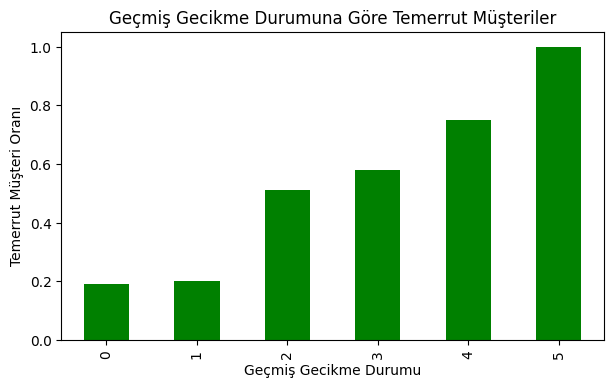

In [31]:
plt.figure(figsize=(7,4))
gecikme_tablosu["Temerrut"].plot(kind="bar", color="g")
plt.title("Geçmiş Gecikme Durumuna Göre Temerrut Müşteriler")
plt.xlabel("Geçmiş Gecikme Durumu")
plt.ylabel("Temerrut Müşteri Oranı")
plt.show()

In [ ]:
# Ev durumu ve kredi amacı ile kredi ödeme durumu analiz tablosu.

